In [ ]:
# Parte 0: Construcción de la tabla analítica

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving team_1_export.zip to team_1_export.zip


In [ ]:
import zipfile
import os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("team_1_export")

print(os.listdir("team_1_export")[:10])

['Team16', 'grd_team21 (1).csv', 'Team09', 'Team07', 'Team02', 'eno_team01.csv', 'Team11', 'Team04', 'Team17', 'census_team21 (1).csv']


In [ ]:
import pandas as pd
import glob

ruta = "team_1_export/**/*.csv"

archivos = glob.glob(ruta, recursive=True)

census_files = [f for f in archivos if "census" in f.lower()]
eno_files = [f for f in archivos if "eno" in f.lower()]
grd_files = [f for f in archivos if "grd" in f.lower()]

print("Archivos census:", len(census_files))
print("Archivos eno:", len(eno_files))
print("Archivos grd:", len(grd_files))

census_master = pd.concat([pd.read_csv(f) for f in census_files])
eno_master = pd.concat([pd.read_csv(f) for f in eno_files])
grd_master = pd.concat([pd.read_csv(f) for f in grd_files])

print("Census:", census_master.shape)
print("ENO:", eno_master.shape)
print("GRD:", grd_master.shape)

Archivos census: 16
Archivos eno: 16
Archivos grd: 16
Census: (38, 13)
ENO: (38, 8)
GRD: (38, 13)


In [ ]:
df_final = census_master.merge(eno_master, on="codigo_comuna", how="outer")
df_final = df_final.merge(grd_master, on="codigo_comuna", how="outer")

print(df_final.shape)
df_final.head()

(44, 32)


,codigo_comuna,nombre_comuna_x,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,...,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,5101,Valparaíso,284938,272618,12320,4.320000,36.8,30.1,11.400000,11.900000,...,22541,1639,6.780000,5.600000,5.700000,4.900000,1.920000,2.840000,Embarazo y parto | Enfermedades circulatorias ...,848.61000
1,5102,Casablanca,29876,27607,2269,7.590000,34.5,28.7,10.800000,10.300000,...,1963,171,8.010000,4.800000,4.900000,4.100000,1.780000,2.150000,Embarazo y parto | Enfermedades digestivas | E...,714.29000
2,13101,Santiago,5806,258429,176956,3047.812608,35.0,34.0,14.421518,13.805328,...,35664,19265,35.072548,6.682745,7.682129,4.817208,1.615485,2.799978,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",94607.30279
3,13102,Cerrillos,85041,71466,12732,15.000000,36.0,34.0,11.725000,11.439000,...,6681,942,12.360000,7.390000,7.710000,5.110000,1.700000,3.270000,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,896.39000
4,13105,Estación Central,155257,142967,11347,7.300000,37.0,32.0,10.960000,12.194000,...,12314,5132,29.420000,6.530000,7.220000,4.870000,1.650000,2.720000,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,1123.69000


In [ ]:
df_final.columns

Index(['codigo_comuna', 'nombre_comuna_x', 'pop_total', 'pop_chilean',
       'pop_foreign', 'pct_foreign', 'median_age_chilean',
       'median_age_foreign', 'mean_schooling_chilean',
       'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign',
       'dependency_ratio', 'nombre_comuna_y', 'eno_total', 'eno_chilean',
       'eno_foreign', 'eno_desconocido', 'eno_top3_diseases',
       'eno_rate_per_10k', 'nombre_comuna', 'grd_total', 'grd_chilean',
       'grd_foreign', 'grd_pct_foreign', 'grd_mean_los',
       'grd_mean_los_chilean', 'grd_mean_los_foreign', 'grd_mean_severity',
       'grd_mortality_rate', 'grd_top3_chapters', 'grd_rate_per_10k',
       'log_pop_total'],
      dtype='object')

In [ ]:
import numpy as np
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
# log población
df_final["log_pop_total"] = np.log(df_final["pop_total"])

# desempleo (ahora correcto)
df_final["pct_unemployed"] = 100 - df_final["emp_rate_chilean"]

# brecha educacional
df_final["schooling_gap"] = (
    df_final["mean_schooling_chilean"] -
    df_final["mean_schooling_foreign"]
)

df_final.head()

,codigo_comuna,nombre_comuna_x,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio,nombre_comuna_y,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k,log_pop_total,pct_unemployed,schooling_gap
0,5101,Valparaíso,284938,272618,12320,4.323748,36.8,30.1,11.400000,11.900000,53.900000,63.200000,46.980000,Valparaíso,4821,4312,421,88,Sífilis | VIH | Tuberculosis,169.194702,Valparaíso,24180,22541,1639,6.780000,5.600000,5.700000,4.900000,1.920000,2.840000,Embarazo y parto | Enfermedades circulatorias ...,848.605662,12.560027,46.100000,-0.50000
1,5102,Casablanca,29876,27607,2269,7.594725,34.5,28.7,10.800000,10.300000,56.400000,71.800000,44.210000,Casablanca,312,278,29,5,Sífilis | Coqueluche | VIH,104.431651,Casablanca,2134,1963,171,8.010000,4.800000,4.900000,4.100000,1.780000,2.150000,Embarazo y parto | Enfermedades digestivas | E...,714.285714,10.304811,43.600000,0.50000
2,13101,Santiago,5806,258429,176956,3047.812608,35.0,34.0,14.421518,13.805328,72.658632,83.340478,26.210683,Santiago,12186,5059,3635,3492,VIH | Parotiditis | Sifilis,20988.632449,Santiago,54929,35664,19265,35.072548,6.682745,7.682129,4.817208,1.615485,2.799978,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",94607.302790,8.666647,27.341368,0.61619
3,13102,Cerrillos,85041,71466,12732,14.971602,36.0,34.0,11.725000,11.439000,60.800000,69.500000,0.463000,Cerrillos,642,297,101,244,VIH | Parotiditis | Sifilis,75.492997,Cerrillos,7623,6681,942,12.360000,7.390000,7.710000,5.110000,1.700000,3.270000,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,896.391153,11.350889,39.200000,0.28600
4,13105,Estación Central,155257,142967,11347,7.308527,37.0,32.0,10.960000,12.194000,58.800000,71.700000,0.497000,Estación Central,1212,634,111,467,VIH | Parotiditis | Coqueluche,78.064113,Estación Central,17446,12314,5132,29.420000,6.530000,7.220000,4.870000,1.650000,2.720000,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,1123.685244,11.952837,41.200000,-1.23400


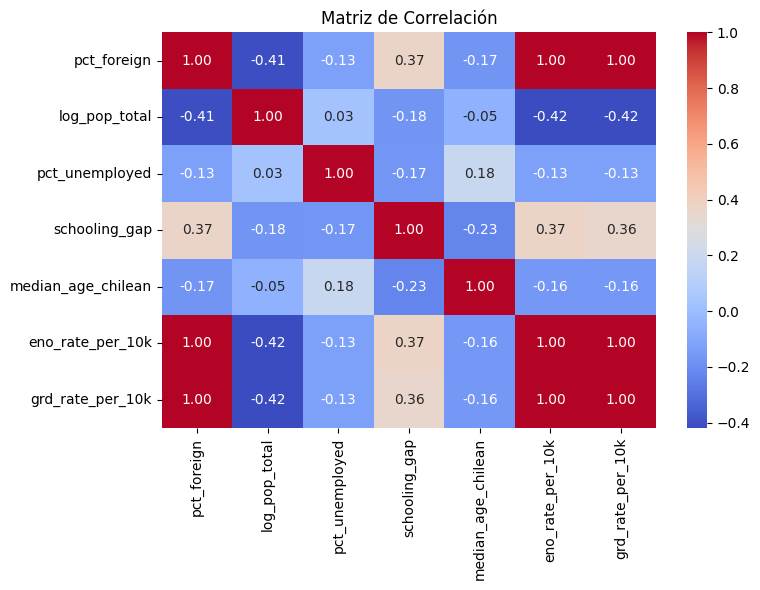

In [ ]:
# Parte 1.1: Matriz de correlación
import seaborn as sns
import matplotlib.pyplot as plt
vars_corr = [
    "pct_foreign",
    "log_pop_total",
    "pct_unemployed",
    "schooling_gap",
    "median_age_chilean",
    "eno_rate_per_10k",
    "grd_rate_per_10k"
]

corr = df_final[vars_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

Se identificó la presencia de valores atípicos extremos que distorsionaban las relaciones observadas. Al excluir estos casos, las correlaciones resultan más moderadas y plausibles, lo que nos indica que los resultados iniciales estaban fuertemente influenciados por outliers.

**LIMPIEZA**

In [ ]:
df_clean = df_final[
    (df_final["pct_foreign"] < 100) &
    (df_final["eno_rate_per_10k"] < 2000) &
    (df_final["grd_rate_per_10k"] < 5000)
]

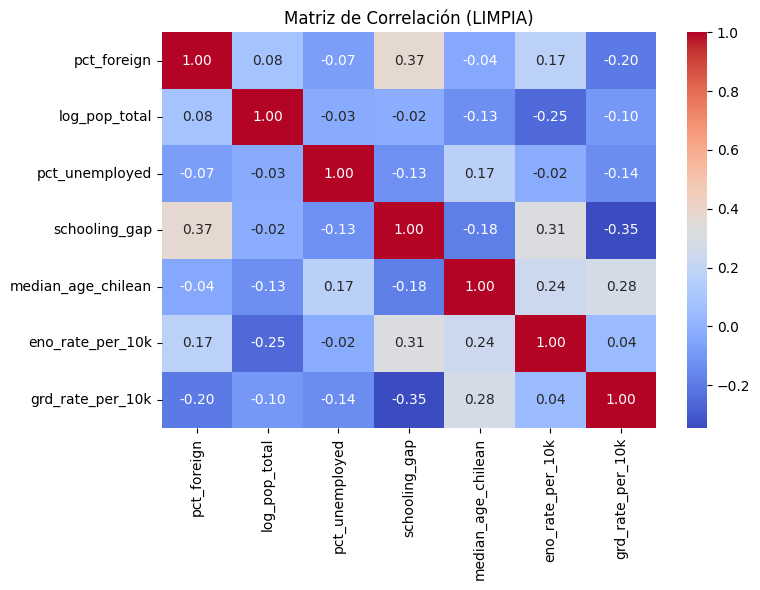

In [ ]:
corr = df_clean[vars_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matriz de Correlación (LIMPIA)")
plt.tight_layout()
plt.show()

A partir de la matriz de correlación, ahora si observamos relaciones moderadas entre las variables demográficas y los resultados de salud.

Inicialmente, los resultados estaban fuertemente influenciados por la presencia de valores atípicos extremos, lo que generaba correlaciones artificialmente altas. Al excluir estos outliers, las relaciones se vuelven más realistas y permiten una mejor interpretación de los datos.

En este contexto, se observamos que pct_foreign presenta una relación débil con las tasas de salud, lo que sugiere que su influencia es menor de lo esperado. Por otro lado, la variable schooling_gap mantiene una correlación positiva moderada con eno_rate_per_10k, lo que podría indicar que mayores brechas educacionales están asociadas a peores resultados sanitarios.

Asimismo, log_pop_total muestra una correlación negativa leve con las tasas de salud, lo que sugiere que comunas más grandes tienden a presentar menores tasas relativas, aunque la relación no es fuerte.

En general, las correlaciones son bajas a moderadas, lo que indica que los resultados de salud no dependen de una sola variable, sino de múltiples factores interrelacionados.

Finalmente, es importante destacar que estas correlaciones no implican causalidad, sino únicamente asociaciones a nivel de comuna, las cuales deben interpretarse con cautela.


**SCATTER**

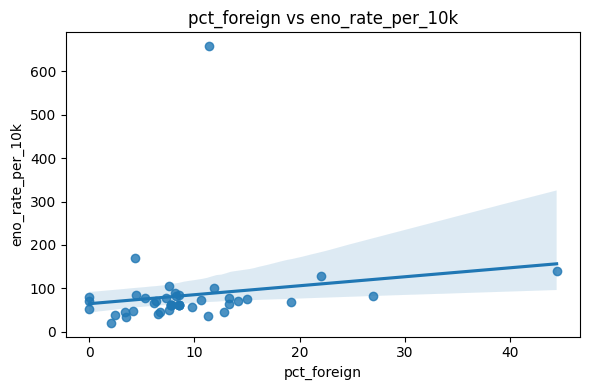

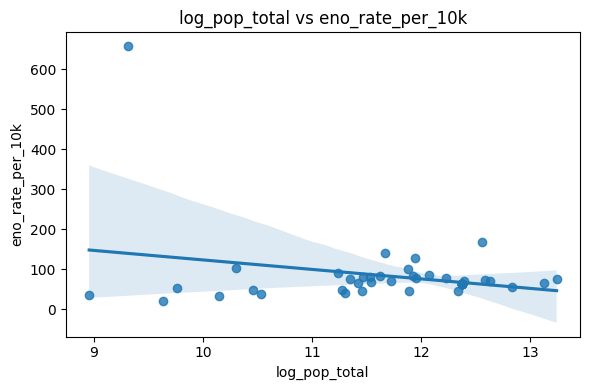

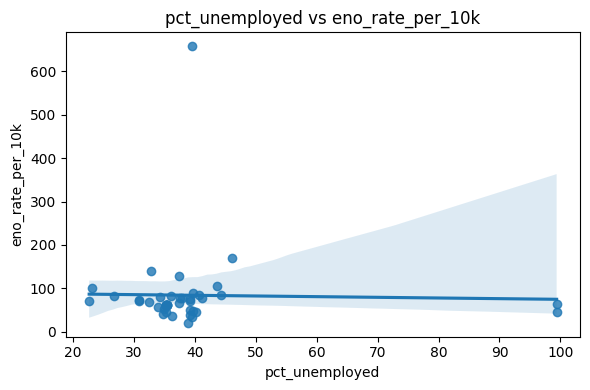

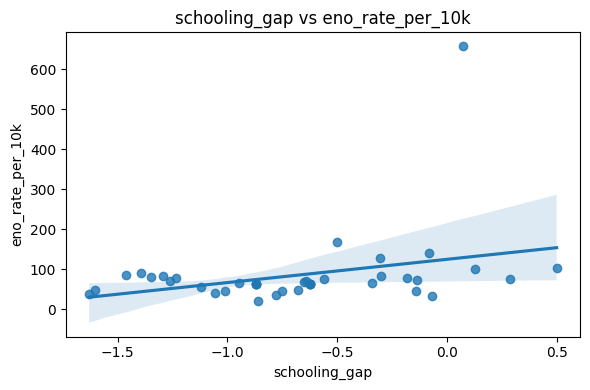

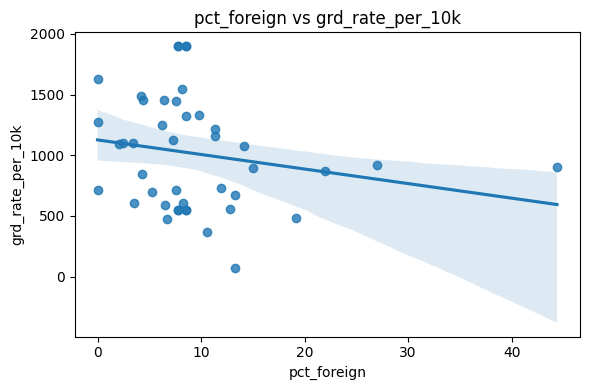

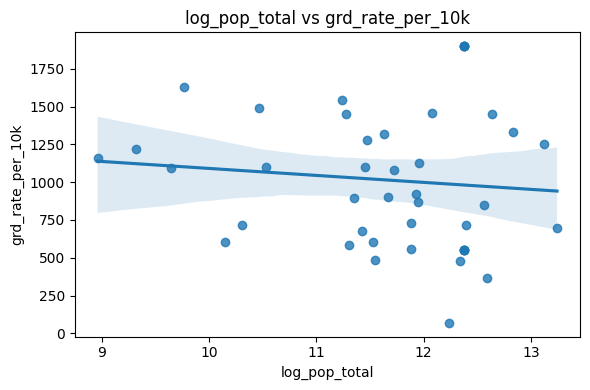

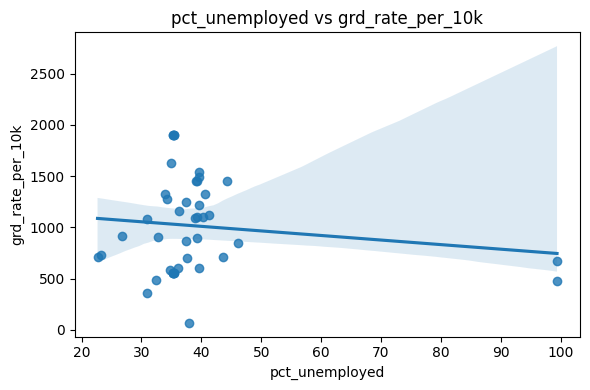

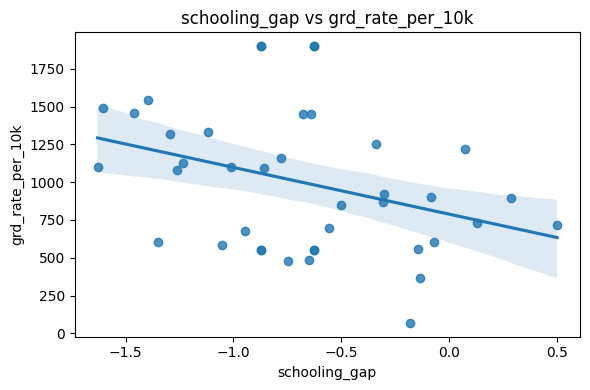

In [ ]:
for y in y_vars:
    for x in x_vars:
        plt.figure(figsize=(6,4))
        sns.regplot(data=df_clean, x=x, y=y)
        plt.title(f"{x} vs {y}")
        plt.tight_layout()
        plt.show()


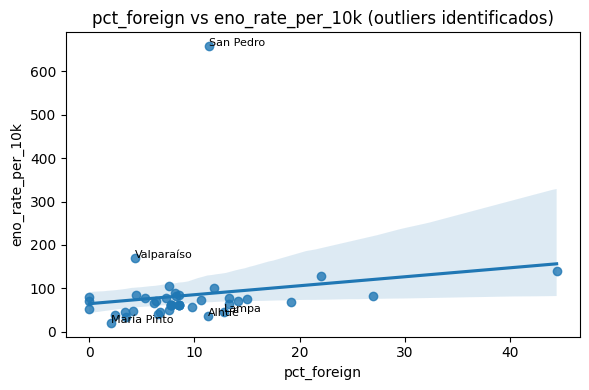

In [ ]:
x = "pct_foreign"
y = "eno_rate_per_10k"
plt.figure(figsize=(6,4))
sns.regplot(data=df_clean, x=x, y=y)
# calculamos residuos
import numpy as np
model = np.polyfit(df_clean[x], df_clean[y], 1)
pred = np.polyval(model, df_clean[x])
residuals = df_clean[y] - pred
# tomamos los 5 más extremos
extreme = residuals.abs().nlargest(5).index
for i in extreme:
    plt.text(df_clean[x][i], df_clean[y][i],
             df_clean["nombre_comuna_x"][i],
             fontsize=8)
plt.title(f"{x} vs {y} (outliers identificados)")
plt.tight_layout()
plt.show()


A partir de los gráficos de dispersión, se identificamos comunas que se comportan como valores atípicos, alejándose de la tendencia general observada.

En particular, la comuna de San Pedro destaca como un outlier extremo, presentando una tasa de notificación ENO considerablemente más alta que el resto, a pesar de tener un nivel moderado de población extranjera. Esto podría explicarse por factores específicos, como la concentración de casos en un centro de salud local o características demográficas particulares.

Asimismo, comunas como Valparaíso también presentan valores superiores al promedio, lo que sugiere diferencias relevantes en la dinámica de salud respecto a otras comunas.

Por otro lado, comunas como María Pinto y Alhué se ubican en la parte inferior del gráfico, reflejando menores tasas de notificación, lo que podría estar asociado a menor densidad poblacional o menor acceso a servicios de salud.

La identificación de estos valores atípicos es fundamental, ya que pueden influir significativamente en los resultados estadísticos y en la interpretación de las relaciones observadas.

 **MODELO POISSON**

In [ ]:

poisson_table = modelo_poisson.summary2().tables[1]

poisson_table = poisson_table[["Coef.", "Std.Err.", "z", "P>|z|", "[0.025", "0.975]"]]

poisson_table.round(4)

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-5.5766,0.0959,-58.1356,0.0000,-5.7646,-5.3886
pct_foreign,0.0092,0.0006,14.1641,0.0000,0.0079,0.0104
schooling_gap,0.2438,0.0121,20.0989,0.0000,0.2200,0.2676
pct_unemployed,-0.0004,0.0003,-1.3343,0.1821,-0.0011,0.0002
median_age_chilean,0.0208,0.0026,7.9365,0.0000,0.0156,0.0259


Modelo Poisson

Se estimó un modelo de regresión Poisson para analizar la relación entre variables demográficas y el número de casos ENO por comuna, incorporando el logaritmo de la población como offset con el fin de ajustar por el tamaño poblacional.

Los resultados nso indicaron que la variable pct_foreign presenta una asociación positiva y estadísticamente significativa con el número de casos ENO, lo que sugiere que comunas con mayor proporción de población extranjera tienden a registrar mayores tasas de notificación.

Asimismo, la variable schooling_gap muestra un efecto positivo y altamente significativo, indicando que mayores brechas educacionales entre población chilena y extranjera están asociadas a un incremento importante en los casos ENO.

Por otro lado, la variable median_age_chilean también presenta una asociación positiva significativa, lo que sugiere que comunas con mayor edad promedio tienden a presentar mayores niveles de notificación.

En contraste, la variable pct_unemployed no resulta estadísticamente significativa, lo que indica que no se observa una relación clara entre el nivel de desempleo y el número de casos ENO en este modelo.

**IRR**

In [ ]:
import numpy as np
irr = np.exp(modelo_poisson.params)
conf = np.exp(modelo_poisson.conf_int())
irr_table = pd.DataFrame({
    "IRR": irr,
    "CI_lower": conf[0],
    "CI_upper": conf[1]
})
irr_table.round(3)

,IRR,CI_lower,CI_upper
Intercept,0.004,0.003,0.005
pct_foreign,1.009,1.008,1.010
schooling_gap,1.276,1.246,1.307
pct_unemployed,1.000,0.999,1.000
median_age_chilean,1.021,1.016,1.026


Interpretación de IRR:

Para facilitar la interpretación de los coeficientes, estos fueron transformados en razones de tasa de incidencia (IRR).

Los resultados muestran que la variable schooling_gap presenta el mayor efecto, con un IRR de aproximadamente 1.28, lo que indica que un aumento en la brecha educacional se asocia con un incremento del 28% en la tasa de casos ENO.

Por su parte, pct_foreign presenta un efecto positivo pero moderado, con un IRR cercano a 1.01, lo que sugiere un aumento leve en la tasa de notificación.

Asimismo, la variable median_age_chilean muestra un efecto positivo, indicando que comunas con mayor edad promedio presentan mayores tasas de casos.

En contraste, pct_unemployed no presenta un efecto relevante, ya que su IRR es cercano a 1.